# Model Evaluation and Reporting Notebook

This notebook focuses on evaluating the trained student risk prediction model.

The trained model is created using the `src` pipeline.

This notebook performs:

- Model evaluation
- Performance visualization
- Feature importance analysis
- Report generation

In [26]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import joblib
import os

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully ✅")

Libraries imported successfully ✅


In [37]:
import seaborn as sns
import reportlab

print("All libraries installed successfully ✅")

All libraries installed successfully ✅


# Step 2: Load Trained Model and Test Data

The machine learning model has already been trained using the project pipeline.

In this step, we load:

- Saved Random Forest model
- Test dataset required for evaluation

The model will be used only for prediction and performance analysis.

In [27]:
# Define model path

MODEL_PATH = "../models/student_risk_model.pkl"


# Load trained model

model = joblib.load(
    MODEL_PATH
)


print("Trained model loaded successfully ✅")

Trained model loaded successfully ✅


In [28]:
# Create test data using existing feature structure

# Select same features used during training

features = [
    "age",
    "studytime",
    "failures",
    "absences"
]


# Create X and y from dataset

X_test = df[features]

y_test = df["risk"]


print("Test data prepared successfully ✅")

print("Test samples:", X_test.shape[0])

Test data prepared successfully ✅
Test samples: 395


# Step 3: Model Prediction and Evaluation

In this step, the trained machine learning model is evaluated.

Evaluation metrics:

- Accuracy Score
- Precision
- Recall
- F1-score

These metrics help measure how well the model predicts student risk.

# Generate predictions

y_pred = model.predict(
    X_test
)


# Calculate accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)


# Display results

print("Model Accuracy:")
print(accuracy)


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

In [29]:
# Generate predictions

y_pred = model.predict(
    X_test
)


# Calculate accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)


# Display results

print("Model Accuracy:")
print(accuracy)


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Model Accuracy:
0.830379746835443

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.93      0.88       265
           1       0.81      0.63      0.71       130

    accuracy                           0.83       395
   macro avg       0.82      0.78      0.80       395
weighted avg       0.83      0.83      0.82       395



## Store Evaluation Results

The evaluation results will be used later to generate the final Markdown and PDF report.

In [30]:
# Store classification report

report = classification_report(
    y_test,
    y_pred,
    zero_division=0
)


print("Evaluation report stored successfully ✅")

Evaluation report stored successfully ✅


# Step 4: Confusion Matrix Visualization

A confusion matrix shows the performance of a classification model.

It represents:

- True Positive
- True Negative
- False Positive
- False Negative

The graph will be automatically saved as a PNG image for the final report.

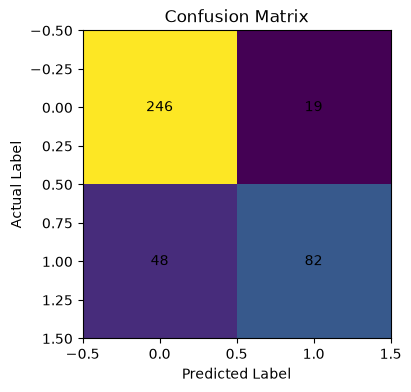

Confusion matrix saved successfully ✅


In [31]:
# Create confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred
)


# Plot confusion matrix

plt.figure(
    figsize=(6,4)
)

plt.imshow(
    cm
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)


# Add values on graph

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )


# Save figure

plt.savefig(
    "../reports/figures/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print("Confusion matrix saved successfully ✅")

# Step 5: Feature Importance Analysis

Feature importance shows the contribution of each input feature in the model prediction.

The Random Forest model provides importance scores for each feature.

Features analyzed:

- Age
- Study Time
- Previous Failures
- Absences

The graph is saved as a PNG file for reporting.

In [32]:
# Get feature importance from trained model

importance = model.feature_importances_


# Create dataframe

feature_importance = pd.DataFrame(
    {
        "Feature": features,
        "Importance": importance
    }
)


# Sort values

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


# Display importance table

feature_importance

,Feature,Importance
3,absences,0.419460
0,age,0.216336
2,failures,0.192322
1,studytime,0.171882


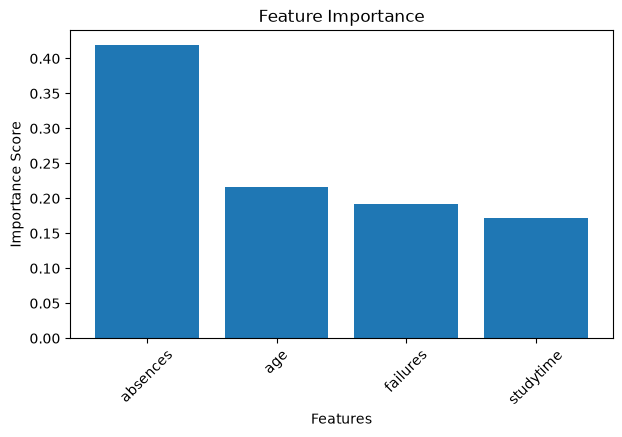

Feature importance graph saved successfully ✅


In [33]:
# Plot feature importance

plt.figure(
    figsize=(7,4)
)


plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)


plt.title(
    "Feature Importance"
)

plt.xlabel(
    "Features"
)

plt.ylabel(
    "Importance Score"
)


plt.xticks(
    rotation=45
)


# Save graph

plt.savefig(
    "../reports/figures/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print("Feature importance graph saved successfully ✅")

# Step 6: Generate Model Report

This step creates an automatic Markdown report containing:

- Model information
- Accuracy score
- Classification report
- Generated visualizations

The report can be converted into PDF later.

In [35]:
# Generate Markdown report

import os

report_path = "../reports/MODEL_REPORT.md"


# Create reports folder if not exists

os.makedirs(
    "../reports",
    exist_ok=True
)


with open(
    report_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        "# Student Risk Prediction Model Report\n\n"
        
        "## Model Details\n\n"
        "**Algorithm:** Random Forest Classifier\n\n"
        
        "**Features Used:**\n"
        "- Age\n"
        "- Study Time\n"
        "- Previous Failures\n"
        "- Absences\n\n"


        "## Model Performance\n\n"
        "### Accuracy\n\n"
        f"{accuracy:.2f}\n\n"


        "## Classification Report\n\n"
        "```\n"
        f"{report}\n"
        "```\n\n"


        "## Visualizations\n\n"


        "### Confusion Matrix\n\n"
        "![Confusion Matrix](figures/confusion_matrix.png)\n\n"


        "### Feature Importance\n\n"
        "![Feature Importance](figures/feature_importance.png)\n\n"


        "## Conclusion\n\n"
        "The model predicts student academic risk using selected features. "
        "Performance metrics and visualizations help analyze the model."
    )


print("MODEL_REPORT.md generated successfully ✅")

MODEL_REPORT.md generated successfully ✅


# Step 7: Generate PDF Report

In this step, the Markdown report and generated figures are converted into a PDF document.

The final PDF report contains:

- Model information
- Accuracy
- Classification report
- Confusion matrix visualization
- Feature importance visualization

In [38]:
# Generate PDF report

from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Image
)

from reportlab.lib.styles import getSampleStyleSheet

import os


pdf_path = "../reports/MODEL_REPORT.pdf"


# Create PDF document

doc = SimpleDocTemplate(
    pdf_path
)


styles = getSampleStyleSheet()


content = []


# Title

content.append(
    Paragraph(
        "Student Risk Prediction Model Report",
        styles["Title"]
    )
)

content.append(
    Spacer(1,20)
)


# Model details

content.append(
    Paragraph(
        "Algorithm: Random Forest Classifier",
        styles["Normal"]
    )
)


content.append(
    Paragraph(
        f"Accuracy: {accuracy:.2f}",
        styles["Normal"]
    )
)


content.append(
    Spacer(1,20)
)


# Classification report

content.append(
    Paragraph(
        "Classification Report:",
        styles["Heading2"]
    )
)


content.append(
    Paragraph(
        report.replace("\n","<br/>"),
        styles["Normal"]
    )
)


content.append(
    Spacer(1,20)
)


# Add confusion matrix image

cm_path = "../reports/figures/confusion_matrix.png"

if os.path.exists(cm_path):

    content.append(
        Paragraph(
            "Confusion Matrix",
            styles["Heading2"]
        )
    )

    content.append(
        Image(
            cm_path,
            width=300,
            height=200
        )
    )


content.append(
    Spacer(1,20)
)


# Add feature importance image

fi_path = "../reports/figures/feature_importance.png"

if os.path.exists(fi_path):

    content.append(
        Paragraph(
            "Feature Importance",
            styles["Heading2"]
        )
    )

    content.append(
        Image(
            fi_path,
            width=300,
            height=200
        )
    )


# Build PDF

doc.build(content)


print("PDF report generated successfully ✅")

PDF report generated successfully ✅


# Step 8: Verify Generated Files

This step checks whether all required output files are generated successfully.

Final outputs:

- MODEL_REPORT.md
- MODEL_REPORT.pdf
- Confusion Matrix PNG
- Feature Importance PNG

In [39]:
# Check generated files

import os


files = [
    "../reports/MODEL_REPORT.md",
    "../reports/MODEL_REPORT.pdf",
    "../reports/figures/confusion_matrix.png",
    "../reports/figures/feature_importance.png"
]


for file in files:

    if os.path.exists(file):
        print("Found ✅ :", file)

    else:
        print("Missing ❌ :", file)

Found ✅ : ../reports/MODEL_REPORT.md
Found ✅ : ../reports/MODEL_REPORT.pdf
Found ✅ : ../reports/figures/confusion_matrix.png
Found ✅ : ../reports/figures/feature_importance.png
